# Functions

Allow for chunks of code to be created and called later when needed.

In [1]:
# Calculate tip amount

def calculate_total(amount, tipPercentage):
    tipCalc = amount * tipPercentage / 100
    return tipCalc


results = calculate_total(37, 15)

print(results)

5.55


## Invoice Generator

In [2]:
def generateInvoice(client, project, amount, dueDate):
    print(f"Hello {client}, your invoice for {project} is ${amount:.2f} and is due on {dueDate}.")



generateInvoice("Acme Corp", "Exloding Trap", 1000.00, "4/30/2026")
generateInvoice("Dynamite Inc", "TNT", 500.00, "5/30/2026")

Hello Acme Corp, your invoice for Exloding Trap is $1000.00 and is due on 4/30/2026.
Hello Dynamite Inc, your invoice for TNT is $500.00 and is due on 5/30/2026.


# Matplot Examples

In [3]:
import pandas as pd
import matplotlib.pyplot as plt  # Can be added by running the following from the terminal "uv add matplotlib"

resultsdf = pd.read_csv("http://128.198.162.191/dataFiles/OLYMPICS/olympics_1896-2024.csv")

resultsdf.head()

,Year,City,Sport,Discipline,Athlete,Country,Gender,EventType,Medal
0,2024,Paris,Cycling Road,Men Individual Time Trial,Evenepoel Remco,Belgium,Male,Athlete,Gold
1,2024,Paris,Cycling Road,Men Individual Time Trial,Ganna Filippo,Italy,Male,Athlete,Silver
2,2024,Paris,Cycling Road,Men Individual Time Trial,Van Aert Wout,Belgium,Male,Athlete,Bronze
3,2024,Paris,Cycling Road,Women Individual Time Trial,Brown Grace,Australia,Female,Athlete,Gold
4,2024,Paris,Cycling Road,Women Individual Time Trial,Henderson Anna,Great Britain,Female,Athlete,Silver


## Medals won by Country

In [4]:
medalsByCountry = resultsdf.groupby('Country')['Medal'].count().sort_values(ascending=False)

medalsByCountry

Country
United States of America    3424
Germany                     1280
Soviet Union                1272
Great Britain               1207
France                      1139
                            ... 
Paraguay                       1
Guyana                         1
Iraq                           1
Samoa                          1
Sudan                          1
Name: Medal, Length: 162, dtype: int64

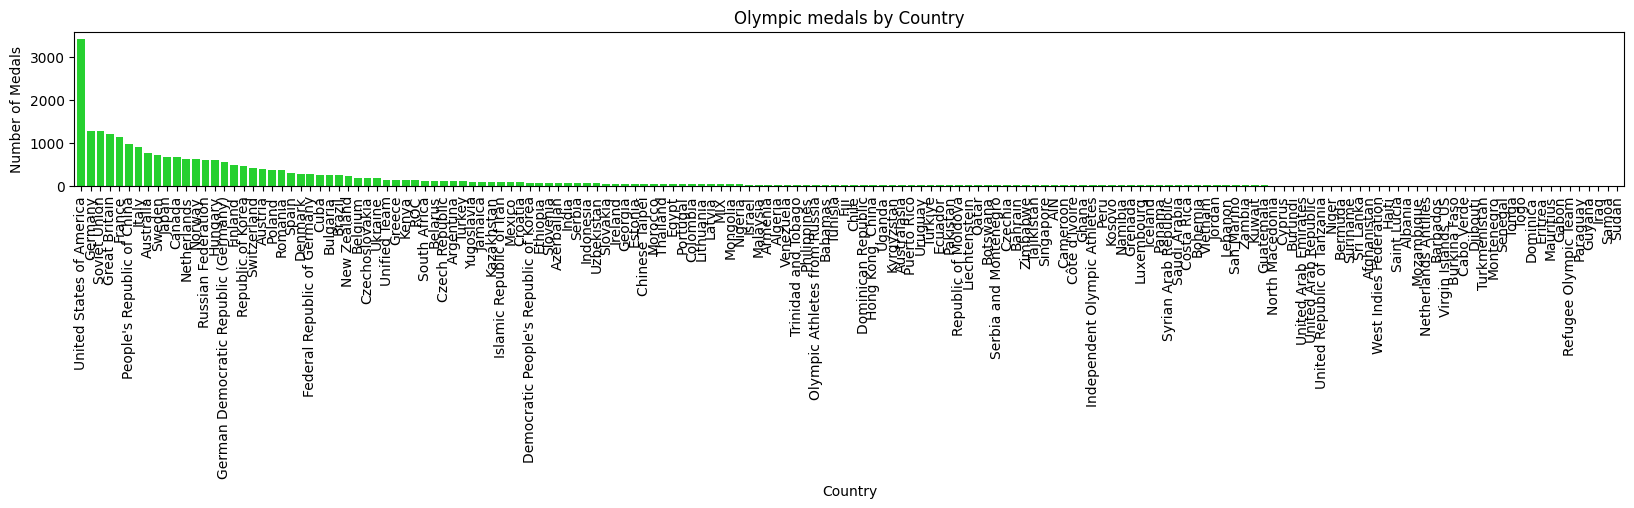

In [5]:
# Format the chart itself
plt.figure(figsize=(20,2))

# Format the chart type and pass the X then Y values
plt.bar(medalsByCountry.index, medalsByCountry.values, color = "#26d02f")

# Chart look and feel
plt.title("Olympic medals by Country")
plt.xlabel('Country')
plt.ylabel('Number of Medals')
plt.xticks(rotation=90)

# For the graph to start at an X value of 0
plt.margins(x=.002)

plt.show()

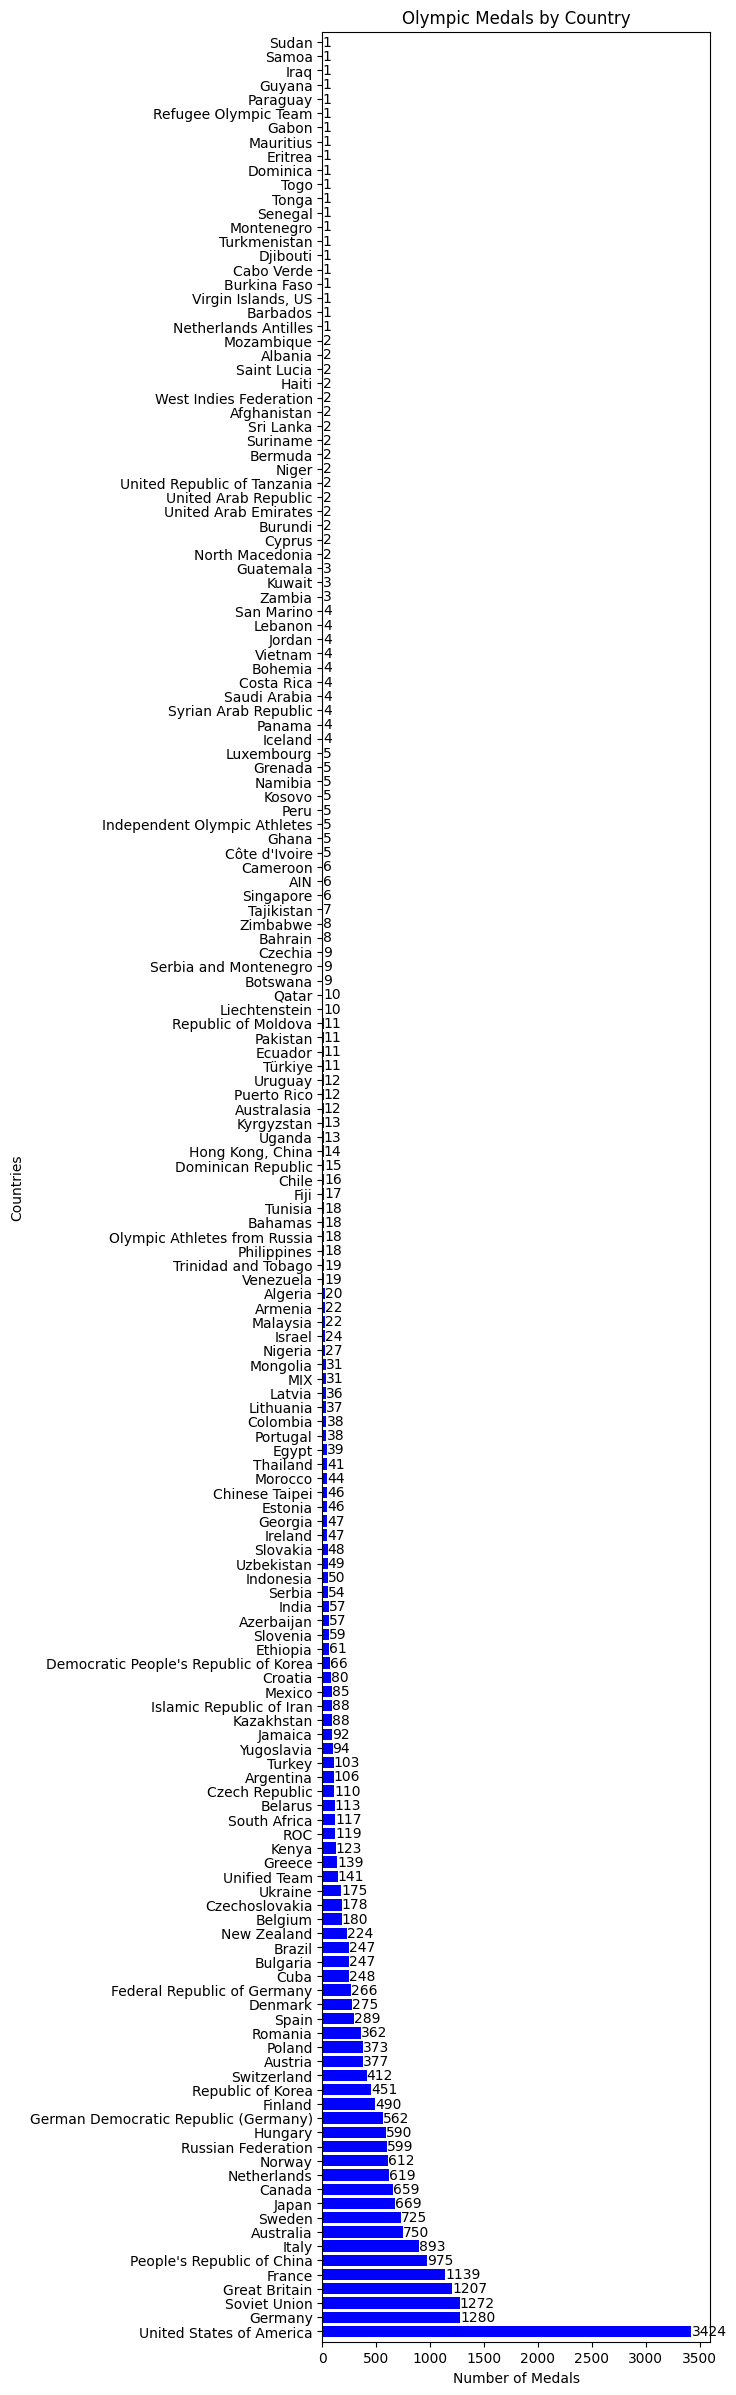

In [6]:
# Vertical bar chart
plt.figure(figsize=(5,30))

# Format the chart
plt.barh(medalsByCountry.index, medalsByCountry.values, color='blue')
plt.title("Olympic Medals by Country")
plt.xlabel('Number of Medals')
plt.ylabel('Countries')
plt.margins(y=.002)

# Invert our Y axis to show the highest medals on top
plt.gca().invert_yaxis # gca stands for "Get Current Axis"

# Add values to the bars
bars = plt.barh(medalsByCountry.index, medalsByCountry.values, color='blue')
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}',
             va='center')

plt.show()

## Pie Chart example
Medals types for the United States

In [7]:
resultsdf.head(1)

,Year,City,Sport,Discipline,Athlete,Country,Gender,EventType,Medal
0,2024,Paris,Cycling Road,Men Individual Time Trial,Evenepoel Remco,Belgium,Male,Athlete,Gold


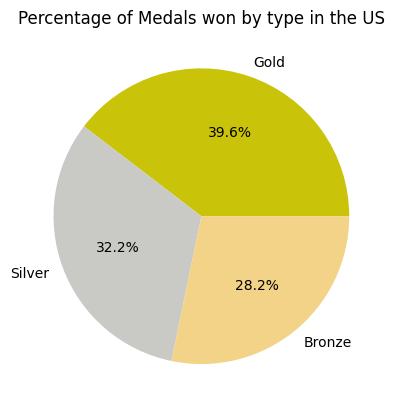

In [8]:
usResults = resultsdf[resultsdf['Country'] == 'United States of America']

# Calculate the medals by type
medalCounts = usResults['Medal'].value_counts()

# Set the colors for the pie chart
color = ['#c9c30a', '#c9cac5', "#f2d387"]

# Create the Pie chart
plt.pie(medalCounts.values, labels=medalCounts.index, autopct='%1.1f%%', colors=color)

plt.title("Percentage of Medals won by type in the US")

plt.show()

## Line Chart

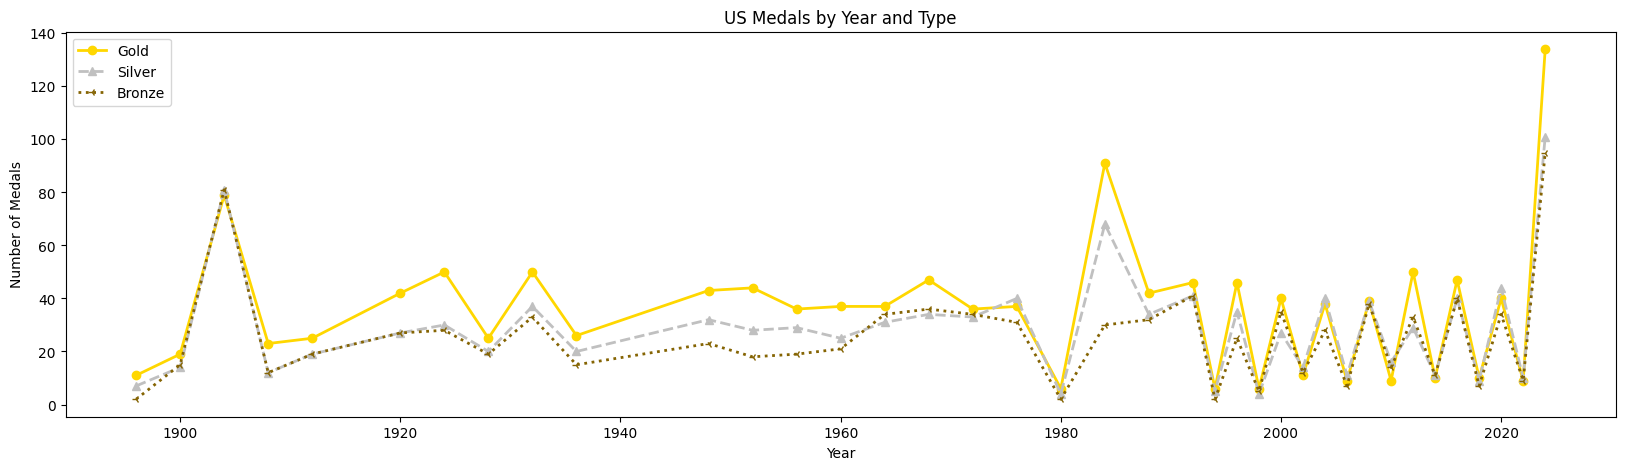

In [9]:
plt.figure(figsize=(20,5))

usGold = resultsdf[(resultsdf.Country == "United States of America") & (resultsdf.Medal == 'Gold')]
usSilver = resultsdf[(resultsdf.Country == "United States of America") & (resultsdf.Medal == 'Silver')]
usBronze = resultsdf[(resultsdf.Country == "United States of America") & (resultsdf.Medal == 'Bronze')]

# Group the data to count the number medals in each category by Year.
usGoldYr = usGold.groupby('Year')['Medal'].count()
usSilverYr = usSilver.groupby('Year')['Medal'].count()
usBronzeYr = usBronze.groupby('Year')['Medal'].count()

# Create our visualization
plt.plot(usGoldYr.index, usGoldYr.values, color='gold', linestyle='-', marker='o', linewidth=2, markersize=6, label="Gold")
plt.plot(usSilverYr.index, usSilverYr.values, color='silver', linestyle='--', marker='^', linewidth=2, markersize=6, label="Silver")
plt.plot(usBronzeYr.index, usBronzeYr.values, color='#856403', linestyle=':', marker='3', linewidth=2, markersize=6, label="Bronze")


# Plot the line chart
plt.title("US Medals by Year and Type")
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.legend() # This adds a legend to explain each line

plt.show()



## Scatter Diagram

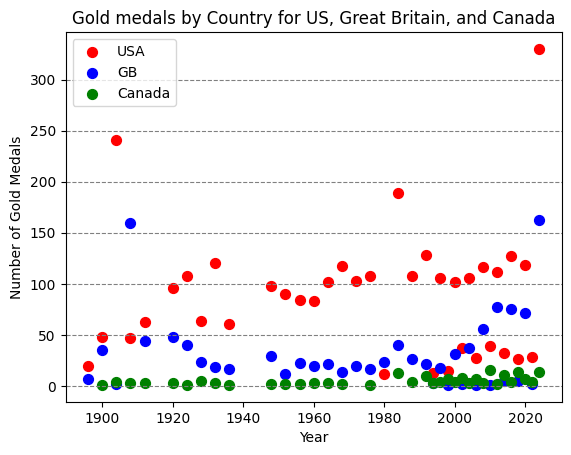

In [11]:
# Compare medals between some Countries
medalsGold = resultsdf[(resultsdf.Country == 'United States of America') |
                       (resultsdf.Country == 'Sweden') |
                       (resultsdf.Country == 'Great Britain')|
                       (resultsdf.Country == 'Canada') &
                       (resultsdf.Medal == 'Gold')]

# Group the data by Year and Country
medalsByYrCountry = medalsGold.groupby(['Year', 'Country']).size().reset_index(name="Gold Medals")

# Group by Year and Country
medalsByYr = medalsGold.groupby('Year')['Medal'].count()

# Create a pivot table with the Years as rows and Countries as columns
medalsPivot = medalsByYrCountry.pivot(index='Year', columns='Country', values='Gold Medals')

# Create our scatter diagram
plt.scatter(medalsPivot.index, medalsPivot['United States of America'], label = 'USA', color = 'red', marker='o', s=50)
plt.scatter(medalsPivot.index, medalsPivot['Great Britain'], label = 'GB', color = 'blue', marker='o', s=50)
plt.scatter(medalsPivot.index, medalsPivot['Canada'], label = 'Canada', color = 'green', marker='o', s=50)


# Create the plot details
plt.title("Gold medals by Country for US, Great Britain, and Canada")
plt.xlabel('Year')
plt.ylabel('Number of Gold Medals')
plt.legend()


plt.grid(axis='y', linestyle='--', color='gray')



# Hurricane examples

In [2]:
# We've already imported pandas and matplot
import pandas as pd
import matplotlib.pyplot as plt

# Import our data
df = pd.read_csv('http://128.198.162.191/dataFiles/HURRICANES/hurdat2-1851-2023-051124.txt')

df.head()

AL011851  \
18510625 0000   HU 28.0N 94.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0    -999.0   
         0600   HU 28.0N 95.4W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0    -999.0   
         1200   HU 28.0N 96.0W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0    -999.0   
         1800   HU 28.1N 96.5W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0    -999.0   
         2100 L HU 28.2N 96.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0    -999.0   

                                                                                                                       UNNAMED  \
18510625 0000   HU 28.0N 94.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0               -999.0   
         0600   HU 28.0N 95.4W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0               -999.0   
         1200   HU 28.0N 96.0W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0               -999.0   
         1800   HU 28.1N 96.5W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0               -999.0   
         2100 L HU 28.2N 96.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0               -999.0   

                                                                                                                14  \
18510625 0000   HU 28.0N 94.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0   -999.0   
         0600   HU 28.0N 95.4W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0   -999.0   
         1200   HU 28.0N 96.0W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0   -999.0   
         1800   HU 28.1N 96.5W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0   -999.0   
         2100 L HU 28.2N 96.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0   -999.0   

                                                                                                           Unnamed: 3  
18510625 0000   HU 28.0N 94.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0      -999.0  
         0600   HU 28.0N 95.4W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0      -999.0  
         1200   HU 28.0N 96.0W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0      -999.0  
         1800   HU 28.1N 96.5W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0      -999.0  
         2100 L HU 28.2N 96.8W 80.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0 -999.0      -999.0

In [3]:
# Define custom labels for my columns
column_names = ['ID-Date', 'Time', 'RecordID', 'Status', 'Latitude', 'Longitude', 'Windspeed', 'Pressure', 'Extra1', 'Extra2', 'Extra3', 'Extra4', 'Extra5',
                'Extra6', 'Extra7', 'Extra8', 'Extra9', 'Extra10', 'Extra11', 'Extra12']

# Use my list of data to update the column names
df = pd.read_csv('http://128.198.162.191/dataFiles/HURRICANES/hurdat2-1851-2023-051124.txt', names=column_names, usecols=range(len(column_names)), on_bad_lines='skip')

df.head()

,ID-Date,Time,RecordID,Status,Latitude,Longitude,Windspeed,Pressure,Extra1,Extra2,Extra3,Extra4,Extra5,Extra6,Extra7,Extra8,Extra9,Extra10,Extra11,Extra12
0,AL011851,UNNAMED,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18510625,0000,,HU,28.0N,94.8W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,18510625,0600,,HU,28.0N,95.4W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,18510625,1200,,HU,28.0N,96.0W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
4,18510625,1800,,HU,28.1N,96.5W,80.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [4]:
# Extract ID, Year and Month from the data
df['YEAR'] = ''
df['MONTH'] =''

# Only extract the year and onth where ID-Date is not blank and has "AL" as an identifier
df.loc[~df['ID-Date'].str.contains('AL'), 'YEAR'] = df['ID-Date'].str[:4]
df.loc[~df['ID-Date'].str.contains('AL'), 'MONTH'] = df['ID-Date'].str[4:6]

# Create a UNIQUE ID column that copies the AL identifier
df["UNIQUE_ID"] = df["ID-Date"].apply(lambda x: x if "AL" in x else None)

# Forward fill the UNIQUE-ID
df['UNIQUE_ID'] = df['UNIQUE_ID'].ffill()

df.head()



,ID-Date,Time,RecordID,Status,Latitude,Longitude,Windspeed,Pressure,Extra1,Extra2,...,Extra6,Extra7,Extra8,Extra9,Extra10,Extra11,Extra12,YEAR,MONTH,UNIQUE_ID
0,AL011851,UNNAMED,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,AL011851
1,18510625,0000,,HU,28.0N,94.8W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1851,06,AL011851
2,18510625,0600,,HU,28.0N,95.4W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1851,06,AL011851
3,18510625,1200,,HU,28.0N,96.0W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1851,06,AL011851
4,18510625,1800,,HU,28.1N,96.5W,80.0,-999.0,-999.0,-999.0,...,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1851,06,AL011851


In [7]:
# Count hurricanes by year
hurricanes_by_yr = df.groupby('YEAR')['UNIQUE_ID'].count().reset_index(name='COUNT')

hurricanes_by_yr

,YEAR,COUNT
0,,1973
1,1851,98
2,1852,134
3,1853,100
4,1854,60
...,...,...
169,2019,493
170,2020,883
171,2021,602
172,2022,471


<function matplotlib.pyplot.show(close=None, block=None)>

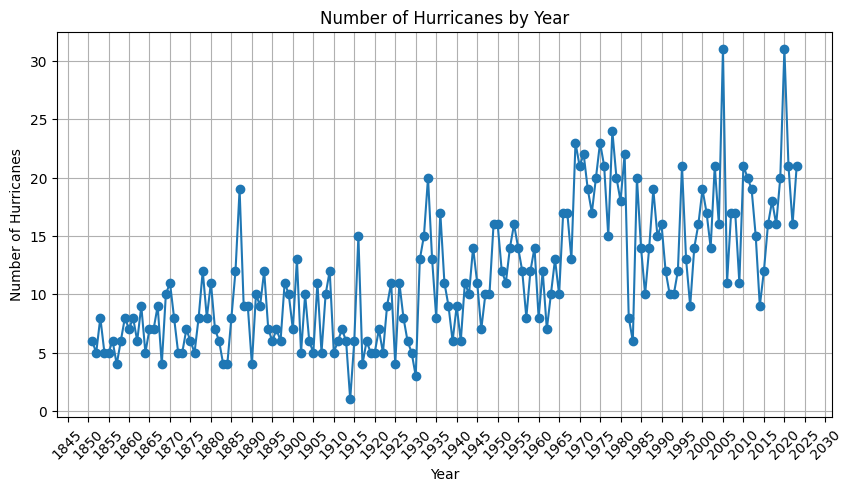

In [11]:
df['YEAR'] = pd.to_numeric(df['YEAR'], errors='coerce')

# Drop any rows where YEAR is NaN
df_clean = df.dropna(subset=['YEAR'])

# Convert YEAR to an Integer
df_clean.loc[:,'YEAR'] = df_clean['YEAR'].astype(int)

# Now we'll group cleaned data
hurricanes_by_year = df_clean.groupby('YEAR')['UNIQUE_ID'].nunique()

# Plot the results
plt.figure(figsize=(10,5))
plt.plot (hurricanes_by_year.index, hurricanes_by_year.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Hurricanes")
plt.title("Number of Hurricanes by Year")

plt.gca().xaxis.set_major_locator(plt.MultipleLocator(5))
plt.xticks(rotation=45)

plt.grid(True)
plt.show